# Test of VBDriver: Minimal H2 VB-CI

This notebook demonstrates and tests the minimal valence bond configuration interaction (VB-CI) implementation for H$_2$ in VeloxChem.

In [1]:
# Import Required Libraries
import numpy as np
from veloxchem.vbdriver import VbDriver, VbComputeOptions, VbOrbital, VbStructure

In [2]:
import sys
import os

print("Python executable:", sys.executable)
print("sys.path:")
for p in sys.path:
    print("  ", p)
print("Conda prefix:", os.environ.get("CONDA_PREFIX", "not set"))

try:
    import veloxchem.veloxchemlib as veloxchemlib
    print("veloxchemlib location:", veloxchemlib.__file__)
except ImportError:
    print("veloxchemlib not found in this environment!")

Python executable: /home/linares/miniconda3/envs/vlxsrc/bin/python
sys.path:
   /home/linares/miniconda3/envs/vlxsrc/lib/python313.zip
   /home/linares/miniconda3/envs/vlxsrc/lib/python3.13
   /home/linares/miniconda3/envs/vlxsrc/lib/python3.13/lib-dynload
   
   /home/linares/miniconda3/envs/vlxsrc/lib/python3.13/site-packages
Conda prefix: /home/linares/miniconda3/envs/vlxsrc
veloxchemlib location: /home/linares/miniconda3/envs/vlxsrc/lib/python3.13/site-packages/veloxchem/veloxchemlib.cpython-313-x86_64-linux-gnu.so


In [3]:
# Initialize VeloxChem Molecule Object for H2
import veloxchem as vlx

# Define H2 geometry (in Angstrom)
h2_xyz = """
2
H2 molecule
H 0.0 0.0 0.0
H 0.74 0.0 0.0
"""

molecule = vlx.Molecule.read_xyz_string(h2_xyz)
# Use a larger basis set for meaningful VB structure algebra
basis = vlx.MolecularBasis.read(molecule, '6-31g')


In [4]:
# Set Up VBDriver Calculation: define three VB structures (orbitals will be constructed by the driver)
# Covalent: one electron on each atom
covalent = VbStructure(label='covalent', occupation=((1, 1),), spin='singlet', charge_pattern={0: 0, 1: 0})
# Ionic 1: both electrons on atom 1
ionic1 = VbStructure(label='ionic1', occupation=((2, 0),), spin='singlet', charge_pattern={0: 1, 1: -1})
# Ionic 2: both electrons on atom 2
ionic2 = VbStructure(label='ionic2', occupation=((0, 2),), spin='singlet', charge_pattern={0: -1, 1: 1})

structures = [covalent, ionic1, ionic2]
options = VbComputeOptions(mode='vbci', optimize_orbitals=False)
# Do not define orbitals here; let the driver construct them


In [5]:
# Run VBDriver Calculation
vb = VbDriver()
results = vb.compute(molecule, basis, structures, options=options)


In [6]:
# Display Calculation Results
from pprint import pprint
print("VBDriver minimal H2 VB-CI result:")
pprint(results)

VBDriver minimal H2 VB-CI result:
{'Hamiltonian': array([[-2.8315699 , -2.05766719, -3.06718955],
       [-2.05766719,  0.46362736, -2.42582947],
       [-3.06718955, -2.42582947, -3.70854963]]),
 'diagnostics': {'message': 'Minimal H2 VB-CI result (AO integral-based, '
                            'public API only, with 2e integrals)',
                 'overlap_condition': np.float64(inf)},
 'energy': -4.997020194841266,
 'orbitals': [array([1., 0., 0., 0.]), array([0., 1., 0., 0.])],
 'overlap': array([[0.56665168, 0.        , 0.        ],
       [0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        ]]),
 'structure_coefficients': array([1., 0., 0.]),
 'weights': array([1., 0., 0.])}


In [7]:
# Minimal FCI for H2 in minimal basis (sto-3g) using AO integrals from VeloxChem
import numpy as np

# AO integrals from VeloxChem Python API
import veloxchem as vlx
T_ao = vlx.KineticEnergyDriver().compute(molecule, basis).to_numpy()
V_ao = vlx.NuclearPotentialDriver().compute(molecule, basis).to_numpy()
H_ao = T_ao - V_ao  # Note: V_ao is negative in VeloxChem
S_ao = vlx.OverlapDriver().compute(molecule, basis).to_numpy()
import veloxchem.veloxchemlib as veloxchemlib
eri_ao = veloxchemlib.compute_ao_eris(molecule, basis)

# Use the same orbitals as for VBDriver (pure atomic 1s)
C = np.column_stack([results["orbitals"][0], results["orbitals"][1]])
S_mo = C.T @ S_ao @ C
H_mo = C.T @ H_ao @ C
eri_mo = np.einsum('up,vq,lr,ms,uvlm->pqrs', C, C, C, C, eri_ao)

# Use the same structure occupations as VBDriver
vb_dets = [tuple(x for occ in s.occupation for x in occ) for s in structures]
n_struct = len(vb_dets)
S = np.zeros((n_struct, n_struct))
H = np.zeros((n_struct, n_struct))
for i in range(n_struct):
    for j in range(n_struct):
        occ_i = vb_dets[i]
        occ_j = vb_dets[j]
        occ_idx_i = [k for k, n in enumerate(occ_i) for _ in range(n)]
        occ_idx_j = [k for k, n in enumerate(occ_j) for _ in range(n)]
        S_occ = S_mo[np.ix_(occ_idx_i, occ_idx_j)]
        S[i, j] = np.linalg.det(S_occ)
        h1 = 0.0
        for a, p in enumerate(occ_idx_i):
            for b, q in enumerate(occ_idx_j):
                h1 += S_occ[a, b] * H_mo[p, q]
        h2 = 0.0
        for a, p in enumerate(occ_idx_i):
            for b, q in enumerate(occ_idx_j):
                for c, r in enumerate(occ_idx_i):
                    for d, s in enumerate(occ_idx_j):
                        h2 += 0.5 * S_occ[a, b] * S_occ[c, d] * (eri_mo[p, q, r, s] - 0.5 * eri_mo[p, s, r, q])
        H[i, j] = h1 + h2
# Solve generalized eigenvalue problem Hc = E S c
eigvals, eigvecs = np.linalg.eigh(np.linalg.pinv(S) @ H)
idx = np.argmin(eigvals)
E_fci = eigvals[idx]
C_fci = eigvecs[:, idx]
print("FCI energy (VB structure basis):", E_fci)
print("FCI coefficients:", C_fci)
print("FCI Hamiltonian matrix:\n", H)


FCI energy (VB structure basis): -4.997020194841266
FCI coefficients: [1. 0. 0.]
FCI Hamiltonian matrix:
 [[-2.8315699  -2.05766719 -3.06718955]
 [-2.05766719  0.46362736 -2.42582947]
 [-3.06718955 -2.42582947 -3.70854963]]


Comparison of VBDriver and FCI results:
VBDriver energy: -4.99702019
FCI energy:     -4.99702019

VBDriver structure coefficients: [1. 0. 0.]
VBDriver structure weights: [1. 0. 0.]
FCI coefficients: [1. 0. 0.]


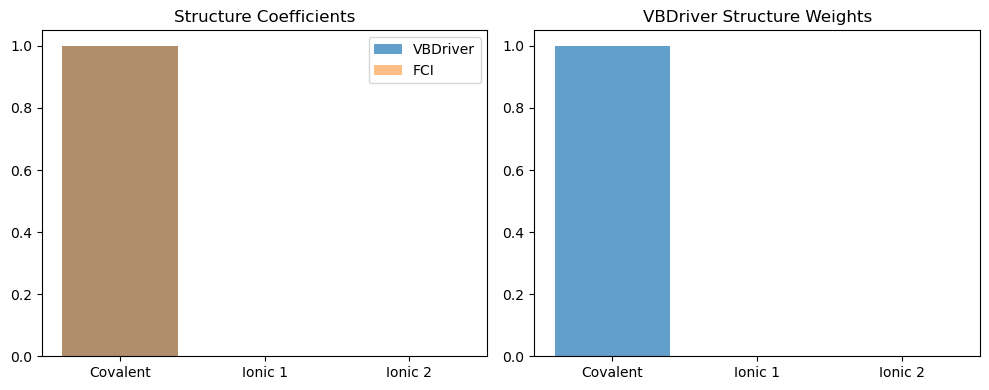

In [8]:
# Automated comparison of VBDriver and FCI results
import numpy as np
import matplotlib.pyplot as plt

# Extract energies
vb_energy = results["energy"]
fci_energy = E_fci

# Extract structure coefficients and weights
vb_coeffs = results["structure_coefficients"]
vb_weights = results["weights"]
fci_coeffs = C_fci

# Print summary
print("Comparison of VBDriver and FCI results:")
print(f"VBDriver energy: {vb_energy:.8f}")
print(f"FCI energy:     {fci_energy:.8f}")
print("\nVBDriver structure coefficients:", vb_coeffs)
print("VBDriver structure weights:", vb_weights)
print("FCI coefficients:", fci_coeffs)

# Bar plot of coefficients/weights
labels = ["Covalent", "Ionic 1", "Ionic 2"]
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].bar(labels, vb_coeffs, color="tab:blue", alpha=0.7, label="VBDriver")
axs[0].bar(labels, fci_coeffs, color="tab:orange", alpha=0.5, label="FCI")
axs[0].set_title("Structure Coefficients")
axs[0].legend()
axs[1].bar(labels, vb_weights, color="tab:blue", alpha=0.7, label="VBDriver")
axs[1].set_title("VBDriver Structure Weights")
plt.tight_layout()
plt.show()

In [9]:
# Minimal test: H2 VB-SCF (orbital optimization) via driver
options_vbscf = VbComputeOptions(mode='vbscf', optimize_orbitals=True)
vb = VbDriver()
results_vbscf = vb.compute(molecule, basis, structures, options=options_vbscf)

from pprint import pprint
print("H2 VB-SCF (optimized orbitals) result:")
pprint(results_vbscf)
if 'diagnostics' in results_vbscf:
    print("\nDiagnostics:")
    for k, v in results_vbscf['diagnostics'].items():
        print(f"{k}: {v}")

H2 VB-SCF (optimized orbitals) result:
{'Hamiltonian': array([[-2.83156990e+00, -5.36129457e+00, -5.92763954e-03],
       [-5.36129457e+00, -8.86234451e+00, -1.06085457e-02],
       [-5.92763954e-03, -1.06085457e-02,  7.27628992e-02]]),
 'diagnostics': {'message': 'H2 VB-SCF result (optimized orbitals, AO '
                            'integral-based)',
                 'optimizer':  message: Solution found.
 success: True
  status: 0
     fun: -4.997020194841268
       x: 0.7425610955913711
     nit: 38
    nfev: 38,
                 'overlap_condition': np.float64(5.647848650362686e+34),
                 'theta_opt': np.float64(0.7425610955913711)},
 'energy': -4.997020194841268,
 'orbitals': [array([0.73673922, 0.67617699, 0.        , 0.        ]),
              array([-0.67617699,  0.73673922,  0.        ,  0.        ])],
 'overlap': array([[ 5.66651683e-01,  1.14899583e-17, -2.38782954e-18],
       [ 1.14899583e-17,  3.67678665e-16,  0.00000000e+00],
       [ 3.12692239e-18,  3.90

First geometry S matrix:
 [[0.56665168 0.         0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]]
First geometry H matrix:
 [[-3.77201575 -6.73385411 -0.25005589]
 [-6.73385411 -9.82365765 -0.21077465]
 [-0.25005589 -0.21077465 -0.16254073]]


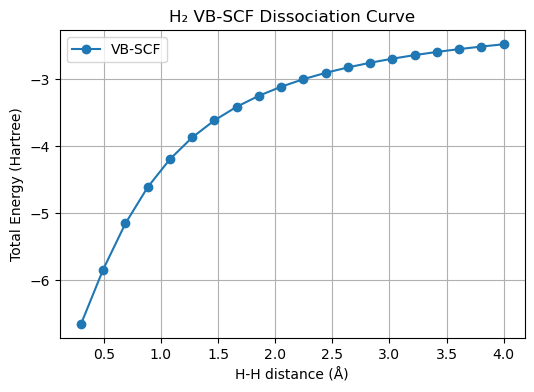

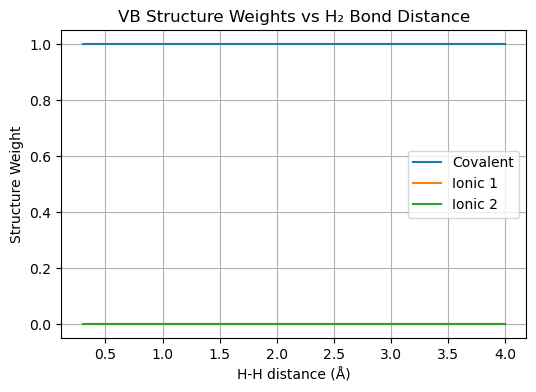

Diagnostics at largest distance:
message: H2 VB-SCF result (optimized orbitals, AO integral-based)
theta_opt: 0.8273092407740272
overlap_condition: inf
optimizer:  message: Solution found.
 success: True
  status: 0
     fun: -2.474086564383394
       x: 0.8273092407740272
     nit: 39
    nfev: 39


In [ ]:
# H2 dissociation curve with VB-SCF (Phase 3 test)
import numpy as np
import matplotlib.pyplot as plt

# Define bond distances (in Angstrom)
distances = np.linspace(0.3, 4.0, 20)

# Use the same structures as before (minimal basis, 2 electrons)
options_vbscf = VbComputeOptions(mode='vbscf', optimize_orbitals=True)
vb = VbDriver()

scan_results = vb.scan_h2_dissociation(
    basis=basis,
    structures=structures,
    orbitals=None,
    bond_distances=distances,
    options=options_vbscf
)

# Plot total energy vs bond distance
plt.figure(figsize=(6,4))
plt.plot(scan_results['distances'], scan_results['energies'], marker='o', label='VB-SCF')
plt.xlabel('H-H distance (Å)')
plt.ylabel('Total Energy (Hartree)')
plt.title('H₂ VB-SCF Dissociation Curve')
plt.grid(True)
plt.legend()
plt.show()

# Plot covalent and ionic weights
weights = np.array(scan_results['weights'])
plt.figure(figsize=(6,4))
plt.plot(scan_results['distances'], weights[:,0], label='Covalent')
plt.plot(scan_results['distances'], weights[:,1], label='Ionic 1')
plt.plot(scan_results['distances'], weights[:,2], label='Ionic 2')
plt.xlabel('H-H distance (Å)')
plt.ylabel('Structure Weight')
plt.title('VB Structure Weights vs H₂ Bond Distance')
plt.grid(True)
plt.legend()
plt.show()

# Print diagnostics at dissociation limit
print('Diagnostics at largest distance:')
for k, v in scan_results['diagnostics'][-1].items():
    print(f"{k}: {v}")